## 1 Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

2025-12-28 22:37:28.342172: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-28 22:37:28.381707: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-28 22:37:29.623317: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-28 22:37:56.852413: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if 'logistic_regression' in sys.modules:
        print("Module 'logistic_regression' found in cache. Forcing reload...")
        importlib.reload(sys.modules['logistic_regression'])
    elif 'utils' in sys.modules:
        print("Module 'utils' found in cache. Forcing reload...")
        importlib.reload(sys.modules['utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    from logistic_regression import LogisticRegression_lr
    import utils as ut
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your 'logistic_regression' folder and 'logistic_regression.py' are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

In [3]:
# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette(sns.color_palette())
np.random.seed(42)
tf.random.set_seed(42)

## 2 Loading and data visualization

In [4]:
# Load the dataset
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

# Separate features and target (using all data)
X_full = df.drop(columns=['Class']).values # Use all 16 features
y_full = df['Class'].values # Use all 7 classes

# Encode the 7 class labels to integers (0 to 6)
label_encoder_full = LabelEncoder()
y_encoded_full = label_encoder_full.fit_transform(y_full)
num_classes = len(label_encoder_full.classes_)
target_names = label_encoder_full.classes_
input_shape = X_full.shape[1] # 16 features

print(f"Full dataset shape: {X_full.shape}")
print(f"Number of classes: {num_classes}")

# Split the full dataset (67% train, 16.5% CV, 16.5% test)
# This uses the same split ratios as the Logistic Regression notebooks
X_train_full, X_, y_train_full, y_ = train_test_split(
    X_full, y_encoded_full, test_size=0.33, random_state=42, stratify=y_encoded_full
)

X_cv_full, X_test_full, y_cv_full, y_test_full = train_test_split(
    X_, y_, test_size=0.5, random_state=42, stratify=y_
)

# Scale all 16 features
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_full)
X_cv_scaled = scaler_full.transform(X_cv_full)
X_test_scaled = scaler_full.transform(X_test_full)

# desired order
labels_desired_order = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

print(f"Train shapes: X={X_train_scaled.shape}, y={y_train_full.shape}")
print(f"CV shapes: X={X_cv_scaled.shape}, y={y_cv_full.shape}")
print(f"Test shapes: X={X_test_scaled.shape}, y={y_test_full.shape}")

# Convert y to one-hot for TensorFlow (categorical crossentropy)
y_train_onehot = tf.keras.utils.to_categorical(y_train_full, num_classes)
y_cv_onehot = tf.keras.utils.to_categorical(y_cv_full, num_classes)
y_test_onehot = tf.keras.utils.to_categorical(y_test_full, num_classes)

Full dataset shape: (13611, 16)
Number of classes: 7
Train shapes: X=(9119, 16), y=(9119,)
CV shapes: X=(2246, 16), y=(2246,)
Test shapes: X=(2246, 16), y=(2246,)


## 3 Model Definition (3 Layers with L2 Regularization)

In [5]:
# Define 3-layer neural network model
def create_model(input_size, hidden_size1, hidden_size2, num_classes, reg=0.0):
    model = Sequential([
        Dense(hidden_size1, activation='relu', input_shape=(input_size,), kernel_regularizer=l2(reg)),  # Layer 1
        Dense(hidden_size2, activation='relu', kernel_regularizer=l2(reg)),  # Layer 2
        Dense(num_classes, activation='softmax', kernel_regularizer=l2(reg))  # Layer 3 (output)
    ])
    return model

# Hyperparameters
input_size = X_full.shape[1]  # 16 features
hidden_size1 = 128
hidden_size2 = 64
learning_rate = 0.001
num_epochs = 100
batch_size = 64

## 4 Training

In [6]:
# Train the model, calculate cost, and plot it
model = create_model(input_size, hidden_size1, hidden_size2, num_classes)
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_scaled, y_train_onehot,
    validation_data=(X_cv_scaled, y_cv_onehot),
    epochs=num_epochs,
    batch_size=batch_size,
    verbose=1
)

print("\nModel Summary:")
model.summary()

/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1766957913.361663   16140 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1766957913.385928   16140 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8312 - loss: 0.6043 - val_accuracy: 0.9172 - val_loss: 0.2546
Epoch 2/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9179 - loss: 0.2366 - val_accuracy: 0.9270 - val_loss: 0.2093
Epoch 3/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9256 - loss: 0.2107 - val_accuracy: 0.9279 - val_loss: 0.2016
Epoch 4/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9267 - loss: 0.2018 - val_accuracy: 0.9270 - val_loss: 0.1980
Epoch 5/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9281 - loss: 0.1967 - val_accuracy: 0.9274 - val_loss: 0.1962
Epoch 6/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9294 - loss: 0.1930 - val_accuracy: 0.9292 - val_loss: 0.1948
Epoch 7/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9297 - loss: 0.1901 - val_accuracy: 0.9297 - val_loss: 0.1941
Epoch 8/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9299 - loss: 0.1878 - val_accu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,663 (127.59 KB)

 Trainable params: 10,887 (42.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,776 (85.07 KB)

## 5 Evaluation and plotting

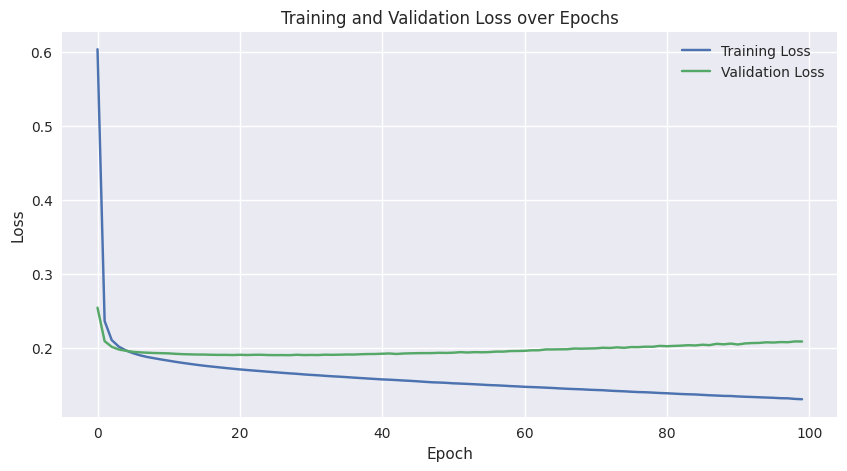

In [7]:
# Plot training cost (loss)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

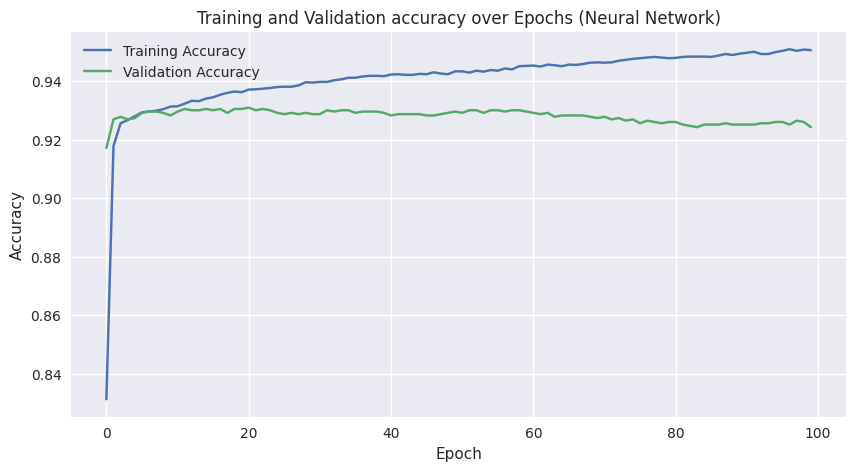

In [8]:
# Plot training cost (loss)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation accuracy over Epochs (Neural Network)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 6 Hyperparameter Regularization

In [13]:
# Hyperparameter regularization (tune L2 regularization)
print('\nHyperparameter Tuning for Regularization (L2):')
reg_values = [0.0, 1e-5, 1e-4, 1e-3]
reg_results = {}

# Best epoch
best_epoch = 60

for reg in reg_values:
    print(f'Training with L2 regularization={reg}')
    model = create_model(input_size, hidden_size1, hidden_size2, num_classes, reg=reg)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(
        X_train_scaled, y_train_onehot,
        epochs=best_epoch,
        batch_size=batch_size,
        verbose=0
    )
    
    # Evaluate on validation set
    val_loss, val_acc = model.evaluate(X_cv_scaled, y_cv_onehot, verbose=0)
    reg_results[reg] = val_acc
    print(f'L2 {reg}: Validation Accuracy {val_acc:.4f}')

# Select best regularization
best_reg = max(reg_results, key=reg_results.get)
print(f'\nBest L2: {best_reg} with Val Acc: {reg_results[best_reg]:.4f}')


Hyperparameter Tuning for Regularization (L2):
Training with L2 regularization=0.0


/mnt/d/Uni/ML/dry-bean-classification/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


L2 0.0: Validation Accuracy 0.9243
Training with L2 regularization=1e-05
L2 1e-05: Validation Accuracy 0.9248
Training with L2 regularization=0.0001
L2 0.0001: Validation Accuracy 0.9297
Training with L2 regularization=0.001
L2 0.001: Validation Accuracy 0.9274

Best L2: 0.0001 with Val Acc: 0.9297


In [14]:
# Retrain with best reg for final evaluation
model = create_model(input_size, hidden_size1, hidden_size2, num_classes, reg=best_reg)
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
history_final = model.fit(
    X_train_scaled, y_train_onehot,
    validation_data=(X_cv_scaled, y_cv_onehot),
    epochs=best_epoch,
    batch_size=batch_size,
    verbose=0
)


Validation Accuracy at Different Epochs:
At epoch 1: 0.9163
At epoch 20: 0.9274
At epoch 40: 0.9274
At epoch 60: 0.9270

Final Test Accuracy: 0.9288
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


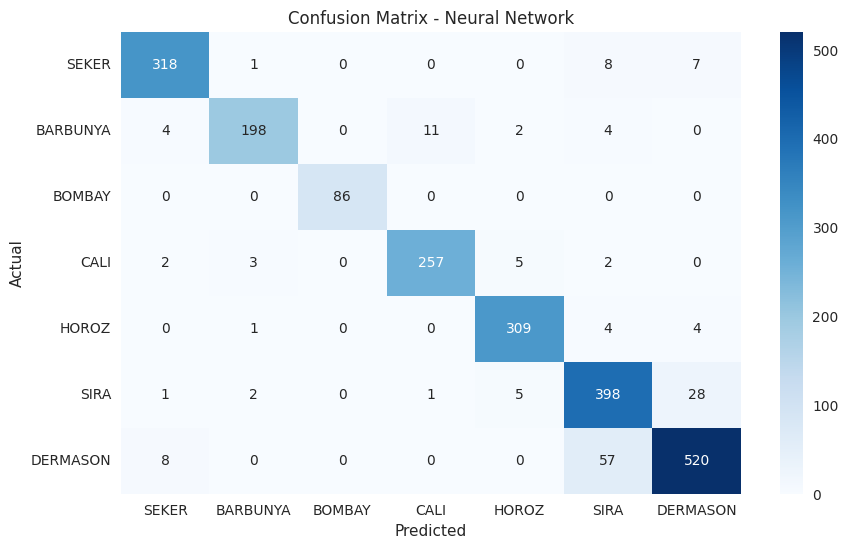

In [16]:
# Evaluate accuracy for different number of iterations (epochs)
# (We can access from history, but since we retrained, simulate by training incrementally)
print('\nValidation Accuracy at Different Epochs:')
val_accuracies = history_final.history['val_accuracy']  # From initial training for illustration

# Generate 4 epoch numbers using linspace from 0 to best_epoch
iterrations = np.linspace(0, best_epoch, 4).astype(int)
# Ensure values are within valid range (1 to best_epoch)
iterrations = np.clip(iterrations, 1, best_epoch)
# Remove duplicates and sort
iterrations = np.unique(iterrations)
for epoch_check in iterrations:
    print(f'At epoch {epoch_check}: {val_accuracies[epoch_check - 1]:.4f}')

# Final test accuracy
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')

# 6. Plot confusion matrix
y_test_pred = np.argmax(model.predict(X_test_scaled), axis=1)
cm = confusion_matrix(y_test_full, y_test_pred, labels=label_encoder_full.transform(labels_desired_order))
conf_df = pd.DataFrame(
    cm,
    index=labels_desired_order, 
    columns=labels_desired_order
)

plt.figure(figsize=(10, 6))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_desired_order,
            yticklabels=labels_desired_order,)
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
# Classification Report
print("\nClassification Report (Test Data):")
report = classification_report(y_test_full, y_test_pred, target_names=labels_desired_order, output_dict=True)
ut.classification_report_to_file(report, "nn")

print(classification_report(y_test_full, y_test_pred, target_names=labels_desired_order))


Classification Report (Test Data):
Metrics saved to 'classification_report/nn.json'
              precision    recall  f1-score   support

       SEKER       0.97      0.90      0.93       219
    BARBUNYA       1.00      1.00      1.00        86
      BOMBAY       0.96      0.96      0.96       269
        CALI       0.93      0.89      0.91       585
       HOROZ       0.96      0.97      0.97       318
        SIRA       0.95      0.95      0.95       334
    DERMASON       0.84      0.91      0.88       435

    accuracy                           0.93      2246
   macro avg       0.94      0.94      0.94      2246
weighted avg       0.93      0.93      0.93      2246

